# Plotting with Matplotlib

### From a blank canvas to clear, useful figures

**Office Hours Workshop · BF550 · Fall 2026**

This is a hands-on notebook. Run the cells, change the values, and ask questions as we go.  
The goal is not to memorize every Matplotlib option—it is to learn a reliable pattern for building and debugging plots.

> **Office hours are open to all course questions.** The Matplotlib theme is simply a shared starting point.


## What you will be able to do

By the end of the workshop, you should be able to:

1. Choose a reasonable chart for a question.
2. Explain the difference between a **Figure** and an **Axes**.
3. Build line, scatter, bar, and histogram plots.
4. Add labels, legends, annotations, and accessible colors.
5. Arrange multiple plots with `subplots`.
6. Diagnose the most common plotting problems.

### The four-pass workflow

| Pass | Question | Typical code |
|---|---|---|
| **1. Question** | What relationship am I trying to show? | — |
| **2. Geometry** | Line, points, bars, or distribution? | `ax.plot`, `ax.scatter`, `ax.bar`, `ax.hist` |
| **3. Meaning** | Can someone understand it without me? | labels, title, legend, units |
| **4. Polish** | Is anything distracting or hard to read? | color, grid, limits, layout |


## How to use this notebook

This workshop has three kinds of material:

- **CORE** — run together during office hours
- **TRY IT** — pause, predict, edit, and rerun
- **DEEP DIVE** — optional material if time permits

### Recommended live-workshop route

**Setup → mental model → line/scatter/bar/histogram → debugging clinic → guided practice**

The remaining sections are useful extensions or take-home practice. In Jupyter, use **Shift + Enter** to run a cell and move forward. If results become confusing, choose **Kernel → Restart Kernel and Run All Cells**; notebooks remember variables from previously run cells, so running out of order can create misleading results.

### Navigation

[Setup](#setup) · [Mental model](#mental-model) · [Line](#line-plots) · [Scatter](#scatter-plots) · [Bar](#bar-charts) · [Histogram](#histograms) · [Subplots](#subplots) · [Debugging](#debugging) · [Practice](#guided-practice) · [Challenge](#mini-challenge)


<a id="setup"></a>
## 0. Setup

We need three standard scientific-Python libraries:

- **NumPy** for arrays and reproducible simulated data
- **pandas** for tables
- **Matplotlib** for plotting

If the import cell fails, install the missing package in the environment used by this notebook, then restart the kernel.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make plots consistent and readable on a projector.
plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 14,
    "legend.frameon": False,
})

# A small, colorblind-friendly palette.
COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "purple": "#CC79A7",
    "gray": "#6B7280",
}

# Reproducible randomness: everyone sees the same data.
rng = np.random.default_rng(550)

print("Ready to plot!")


/Users/myousry/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/dl/7jlhjmsx5ggdymdzhxyl_fjr0000gn/T/matplotlib-sjp6crke because there was an issue with the default path (/Users/myousry/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.



Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/myousry/.cache/fontconfig
	/Users/myousry/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/myousry/.cache/fontconfig
	/Users/myousry/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/myousry/.cache/fontconfig
	/Users/myousry/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/myousry/.cache/fontconfig
	/Users/myousry/.fontconfig


Matplotlib is building the font cache; this may take a moment.


Ready to plot!


## 1. Meet the data

We will use two small datasets:

1. A 14-day plant-growth experiment comparing control and treatment groups.
2. A simulated class dataset relating practice time to quiz score.

The data are created here, so this notebook works without downloads or internet access.


In [2]:
# Dataset 1: measurements over time
days = np.arange(1, 15)
control_growth = np.array([2.1, 2.4, 2.8, 3.0, 3.5, 3.8, 4.1,
                           4.4, 4.8, 5.0, 5.3, 5.6, 5.8, 6.1])
treatment_growth = np.array([2.0, 2.5, 2.9, 3.4, 3.9, 4.3, 4.8,
                             5.3, 5.9, 6.4, 6.9, 7.3, 7.8, 8.2])
temperature = np.array([21.0, 20.5, 21.8, 22.3, 22.0, 23.1, 22.7,
                        23.4, 24.0, 23.6, 24.2, 24.5, 24.1, 25.0])

growth = pd.DataFrame({
    "day": days,
    "control_cm": control_growth,
    "treatment_cm": treatment_growth,
    "temperature_c": temperature,
})

# Dataset 2: one row per student (simulated)
n_students = 60
practice_minutes = rng.integers(10, 121, n_students)
quiz_score = np.clip(
    52 + 0.31 * practice_minutes + rng.normal(0, 8, n_students),
    40,
    100,
)
section = rng.choice(["A", "B"], n_students)

students = pd.DataFrame({
    "practice_minutes": practice_minutes,
    "quiz_score": quiz_score.round(1),
    "section": section,
})

growth.head()


,day,control_cm,treatment_cm,temperature_c
0,1,2.1,2.0,21.0
1,2,2.4,2.5,20.5
2,3,2.8,2.9,21.8
3,4,3.0,3.4,22.3
4,5,3.5,3.9,22.0


### Always inspect before you plot

Before choosing a chart, check:

- What does one row represent?
- Which columns are numeric or categorical?
- Are values missing?
- Are the units what you expect?


In [3]:
print("Growth data shape:", growth.shape)
print("Student data shape:", students.shape)
print("\nStudent column types:")
print(students.dtypes)
print("\nMissing values:")
print(students.isna().sum())


Growth data shape: (14, 4)
Student data shape: (60, 3)

Student column types:
practice_minutes      int64
quiz_score          float64
section                 str
dtype: object

Missing values:
practice_minutes    0
quiz_score          0
section             0
dtype: int64


<a id="mental-model"></a>
## 2. The mental model: Figure → Axes → marks

- A **Figure** is the entire canvas—the object that gets displayed or saved.
- An **Axes** is one plotting area, including its x-axis, y-axis, labels, and title.
- The line, dots, bars, and text drawn on an Axes are the visual **marks**.

```text
Figure
├── Axes 1
│   ├── line / points / bars
│   ├── x-axis and y-axis
│   └── labels, title, legend
└── Axes 2 (optional)
```

The most dependable starting point is:

```python
fig, ax = plt.subplots()
# ask ax to draw something
plt.show()
```

You may also see the stateful `plt` style online. The pairs below are related, but the explicit Axes form scales more cleanly to multiple panels:

| Stateful form | Explicit Axes form |
|---|---|
| `plt.plot(x, y)` | `ax.plot(x, y)` |
| `plt.scatter(x, y)` | `ax.scatter(x, y)` |
| `plt.xlabel("Day")` | `ax.set_xlabel("Day")` |
| `plt.title("Growth")` | `ax.set_title("Growth")` |
| `plt.xlim(0, 10)` | `ax.set_xlim(0, 10)` |


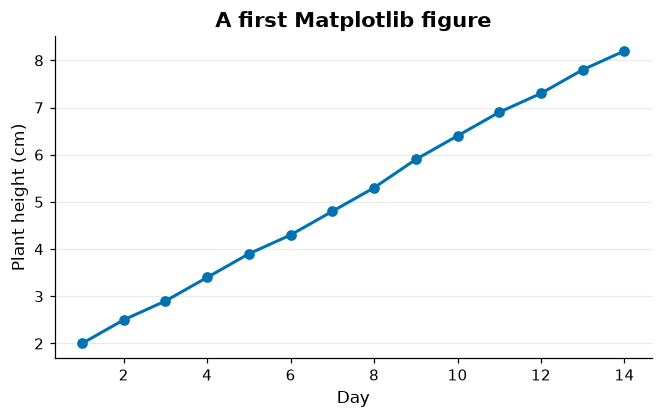

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.8))

ax.plot(growth["day"], growth["treatment_cm"],
        color=COLORS["blue"], marker="o", linewidth=2)

ax.set(
    title="A first Matplotlib figure",
    xlabel="Day",
    ylabel="Plant height (cm)",
)
ax.grid(axis="y", alpha=0.25)

plt.show()


### TRY IT · Inspect the objects

The names `fig` and `ax` are ordinary Python variables. Matplotlib objects remember what has been drawn on them, which means you can inspect or change a chart after creating it.


Figure type: Figure
Axes type: Axes
Axes in this Figure: 1
Lines drawn on this Axes: 1


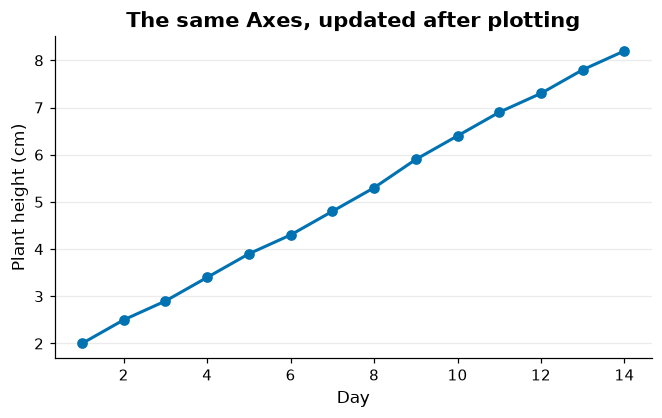

In [5]:
print("Figure type:", type(fig).__name__)
print("Axes type:", type(ax).__name__)
print("Axes in this Figure:", len(fig.axes))
print("Lines drawn on this Axes:", len(ax.lines))

# Try changing the title, then display the same Figure again:
ax.set_title("The same Axes, updated after plotting")
fig


### A chart in one sentence

Read the core line from left to right:

```python
ax.plot(x_values, y_values, color=..., marker=..., label=...)
```

> Put the explanatory or ordered variable on **x** and the measured outcome on **y**.


<a id="line-plots"></a>
## 3. Line plots: change across an ordered axis

Use a line plot when the x-axis has a meaningful order—especially time. Connecting points implies continuity, so a line is usually a poor choice for unrelated categories.


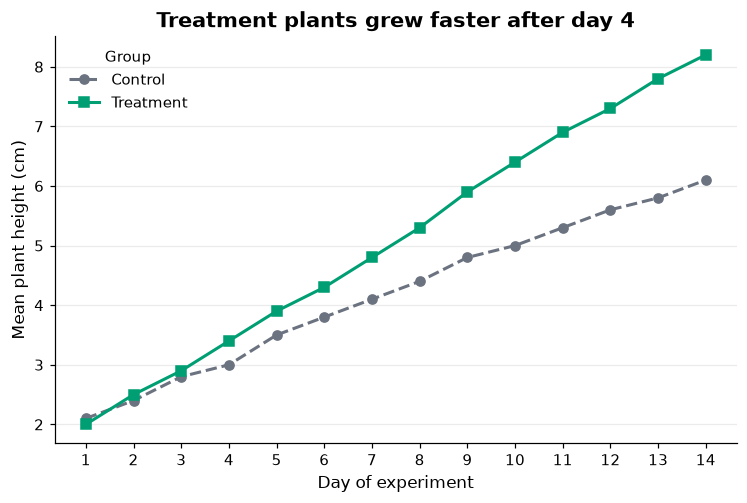

In [6]:
fig, ax = plt.subplots()

ax.plot(growth["day"], growth["control_cm"],
        marker="o", linestyle="--", linewidth=2,
        color=COLORS["gray"], label="Control")
ax.plot(growth["day"], growth["treatment_cm"],
        marker="s", linewidth=2, color=COLORS["green"], label="Treatment")

ax.set(
    title="Treatment plants grew faster after day 4",
    xlabel="Day of experiment",
    ylabel="Mean plant height (cm)",
    xticks=days,
)
ax.legend(title="Group")
ax.grid(axis="y", alpha=0.25)

plt.show()


### TRY IT · One-change-at-a-time style lab

Change one argument in the final line, rerun the cell, and describe exactly what changed. Good experiments: `marker="s"`, `linestyle="--"`, `linewidth=5`, or `alpha=0.3`.


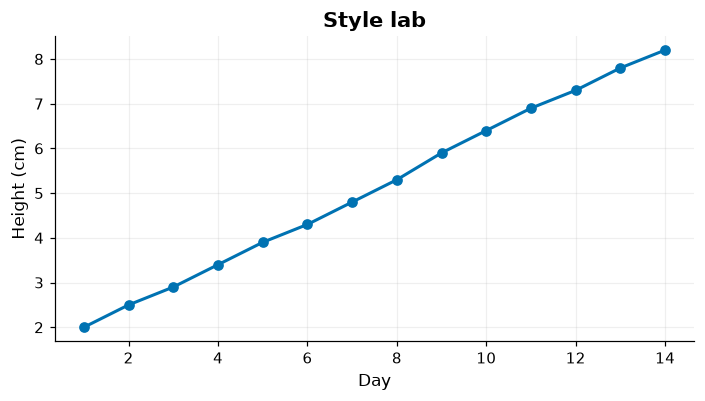

In [7]:
def line_style_lab(marker="o", linestyle="-", linewidth=2, alpha=1.0):
    '''Draw the same data with adjustable visual properties.'''
    fig, ax = plt.subplots(figsize=(7.5, 3.6))
    ax.plot(
        growth["day"],
        growth["treatment_cm"],
        marker=marker,
        linestyle=linestyle,
        linewidth=linewidth,
        alpha=alpha,
        color=COLORS["blue"],
    )
    ax.set(title="Style lab", xlabel="Day", ylabel="Height (cm)")
    ax.grid(alpha=0.2)
    plt.show()


line_style_lab(marker="o", linestyle="-", linewidth=2, alpha=1.0)


### Make the title communicate the takeaway

Compare:

- Generic: **Plant growth**
- Informative: **Treatment plants grew faster after day 4**

The second title tells the reader what to notice, while the axis labels carry the variables and units.


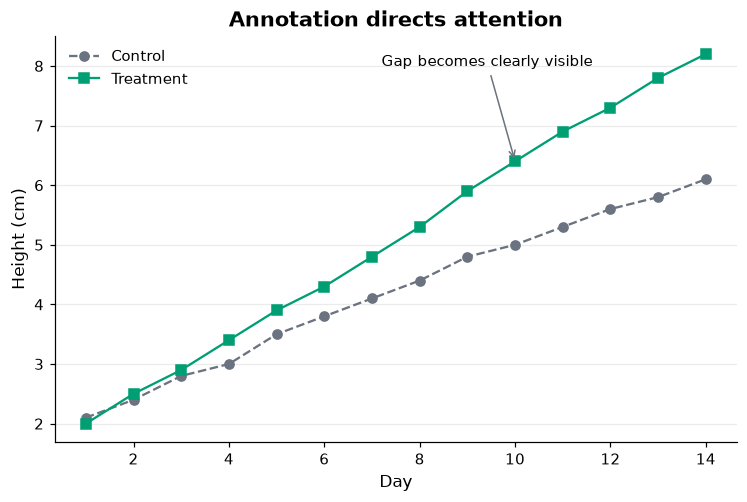

In [8]:
fig, ax = plt.subplots()

ax.plot(growth["day"], growth["control_cm"],
        marker="o", linestyle="--", color=COLORS["gray"], label="Control")
ax.plot(growth["day"], growth["treatment_cm"],
        marker="s", color=COLORS["green"], label="Treatment")

# Draw attention to one meaningful point.
day_to_note = 10
height_to_note = growth.loc[growth["day"] == day_to_note, "treatment_cm"].iloc[0]
ax.annotate(
    "Gap becomes clearly visible",
    xy=(day_to_note, height_to_note),
    xytext=(7.2, 8.0),
    arrowprops={"arrowstyle": "->", "color": COLORS["gray"]},
    fontsize=10,
)

ax.set(title="Annotation directs attention", xlabel="Day", ylabel="Height (cm)")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.show()


### DEEP DIVE · Error bars for summarized measurements

When each point is a summary of repeated measurements, `ax.errorbar` can show uncertainty or variability. Always say what the bars represent—standard deviation, standard error, or a confidence interval are not interchangeable.


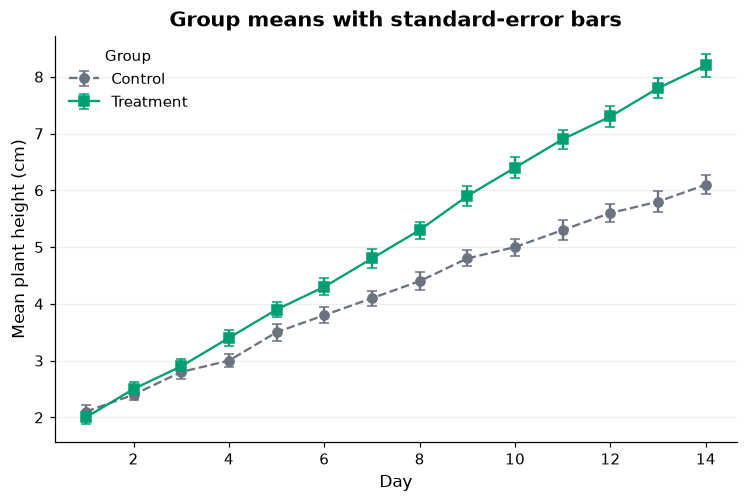

In [9]:
# Example standard errors for the daily group means.
control_se = np.array([0.12, 0.10, 0.13, 0.11, 0.15, 0.14, 0.13,
                       0.16, 0.14, 0.15, 0.17, 0.16, 0.18, 0.17])
treatment_se = np.array([0.11, 0.12, 0.12, 0.14, 0.13, 0.15, 0.16,
                         0.15, 0.17, 0.18, 0.17, 0.19, 0.18, 0.20])

fig, ax = plt.subplots()
ax.errorbar(
    growth["day"], growth["control_cm"], yerr=control_se,
    color=COLORS["gray"], marker="o", linestyle="--",
    capsize=3, label="Control",
)
ax.errorbar(
    growth["day"], growth["treatment_cm"], yerr=treatment_se,
    color=COLORS["green"], marker="s", capsize=3, label="Treatment",
)
ax.set(
    title="Group means with standard-error bars",
    xlabel="Day",
    ylabel="Mean plant height (cm)",
)
ax.legend(title="Group")
ax.grid(axis="y", alpha=0.2)
plt.show()


<a id="scatter-plots"></a>
## 4. Scatter plots: relationships between two numeric variables

Use a scatter plot when each observation has an x-value and a y-value. Look for:

- direction (positive or negative),
- form (linear or curved),
- strength,
- clusters, and
- unusual observations.

Avoid claiming causation from a pattern alone.


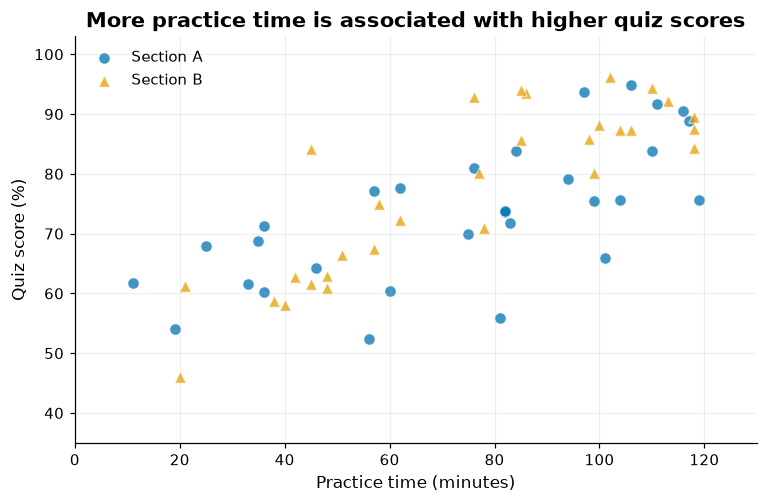

In [10]:
fig, ax = plt.subplots()

for group, color, marker in [
    ("A", COLORS["blue"], "o"),
    ("B", COLORS["orange"], "^"),
]:
    subset = students[students["section"] == group]
    ax.scatter(
        subset["practice_minutes"],
        subset["quiz_score"],
        marker=marker,
        s=55,
        alpha=0.75,
        color=color,
        edgecolor="white",
        linewidth=0.6,
        label=f"Section {group}",
    )

ax.set(
    title="More practice time is associated with higher quiz scores",
    xlabel="Practice time (minutes)",
    ylabel="Quiz score (%)",
    xlim=(0, 130),
    ylim=(35, 103),
)
ax.legend()
ax.grid(alpha=0.2)

plt.show()


### Accessibility check

Section is encoded with both **color** and **marker shape**, so the groups remain distinguishable when printed in grayscale or viewed by someone with color-vision differences. Avoid relying on color alone whenever the distinction matters.

**Quick read:** What does position encode? What do color and shape encode? Is anything in this chart merely decorative?


### Optional: add a simple trend line

`np.polyfit(x, y, 1)` estimates a straight line with a slope and intercept. The line summarizes the overall direction; it does not prove that x causes y.


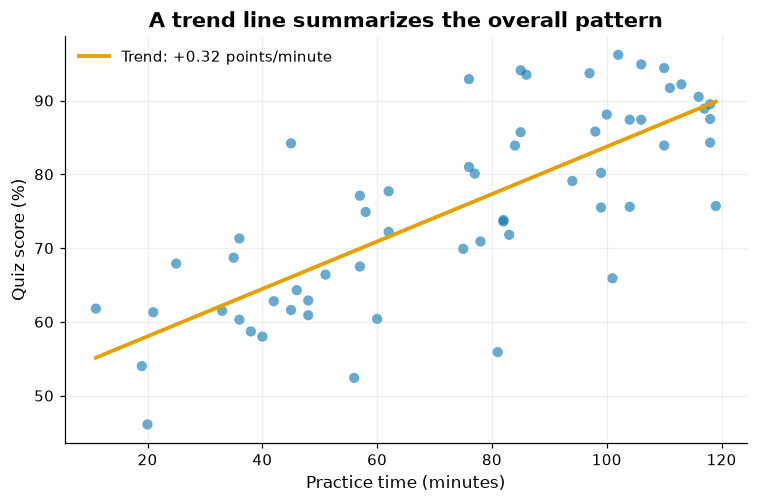

In [11]:
x = students["practice_minutes"]
y = students["quiz_score"]

slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots()
ax.scatter(x, y, s=45, alpha=0.6, color=COLORS["blue"], edgecolor="none")
ax.plot(x_line, y_line, color=COLORS["orange"], linewidth=2.5,
        label=f"Trend: +{slope:.2f} points/minute")

ax.set(
    title="A trend line summarizes the overall pattern",
    xlabel="Practice time (minutes)",
    ylabel="Quiz score (%)",
)
ax.legend()
ax.grid(alpha=0.2)

plt.show()


<a id="bar-charts"></a>
## 5. Bar charts: compare categories

Bar length represents a value. Start the value axis at zero unless you have a very strong reason not to—truncating it can exaggerate small differences.


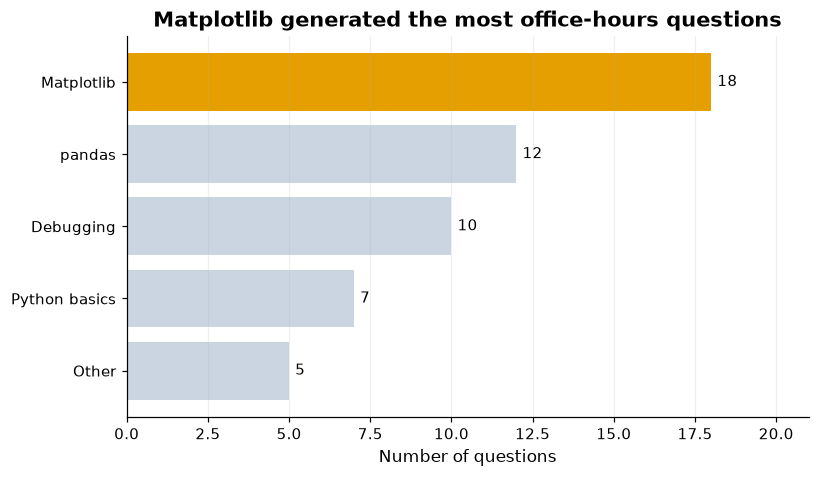

In [12]:
topics = pd.Series({
    "Python basics": 7,
    "pandas": 12,
    "Matplotlib": 18,
    "Debugging": 10,
    "Other": 5,
}, name="questions")

# Sorting often makes comparisons faster.
topics_sorted = topics.sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(
    topics_sorted.index,
    topics_sorted.values,
    color=[COLORS["orange"] if topic == "Matplotlib" else "#CBD5E1"
           for topic in topics_sorted.index],
)

ax.bar_label(bars, padding=4)
ax.set(
    title="Matplotlib generated the most office-hours questions",
    xlabel="Number of questions",
    ylabel="",
    xlim=(0, 21),
)
ax.grid(axis="x", alpha=0.2)

plt.show()


### Design principle: emphasize one thing

Color is most effective when it has a job. Here, one orange bar highlights the workshop topic; neutral bars provide context. A rainbow of unrelated colors would add noise.


<a id="histograms"></a>
## 6. Histograms: show a numeric distribution

A histogram groups numeric values into intervals called **bins**. It helps reveal the center, spread, skew, multiple peaks, or unusual values.

The shape can change when the bin count changes, so try several reasonable values rather than accepting the default blindly.


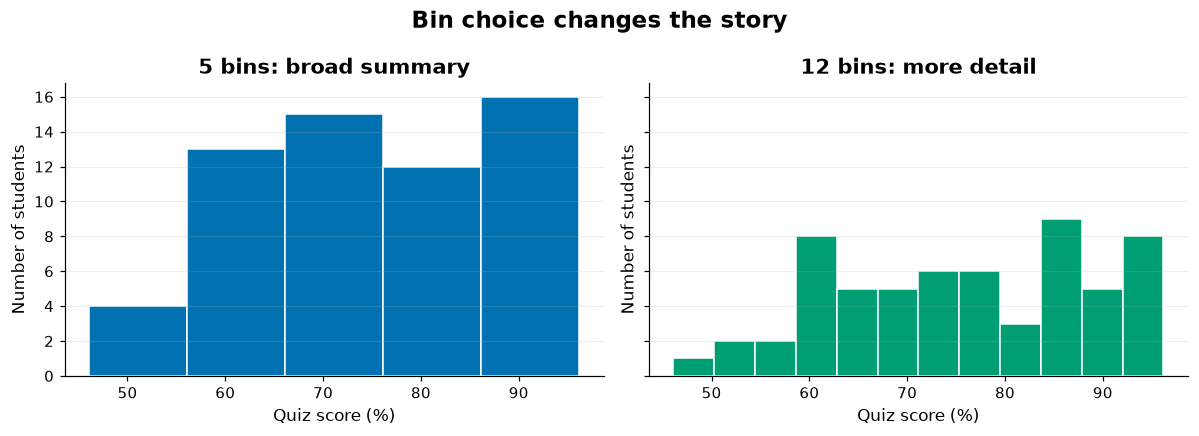

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

axes[0].hist(students["quiz_score"], bins=5,
             color=COLORS["blue"], edgecolor="white")
axes[0].set_title("5 bins: broad summary")

axes[1].hist(students["quiz_score"], bins=12,
             color=COLORS["green"], edgecolor="white")
axes[1].set_title("12 bins: more detail")

for ax in axes:
    ax.set(xlabel="Quiz score (%)", ylabel="Number of students")
    ax.grid(axis="y", alpha=0.2)

fig.suptitle("Bin choice changes the story", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()


<a id="subplots"></a>
## 7. Small multiples with `subplots`

Use multiple Axes when related views answer different parts of the same question. `plt.subplots(rows, columns)` returns:

- one Figure, and
- one Axes or an array of Axes.

Shared scales (`sharex=True` or `sharey=True`) make comparisons more honest and efficient.


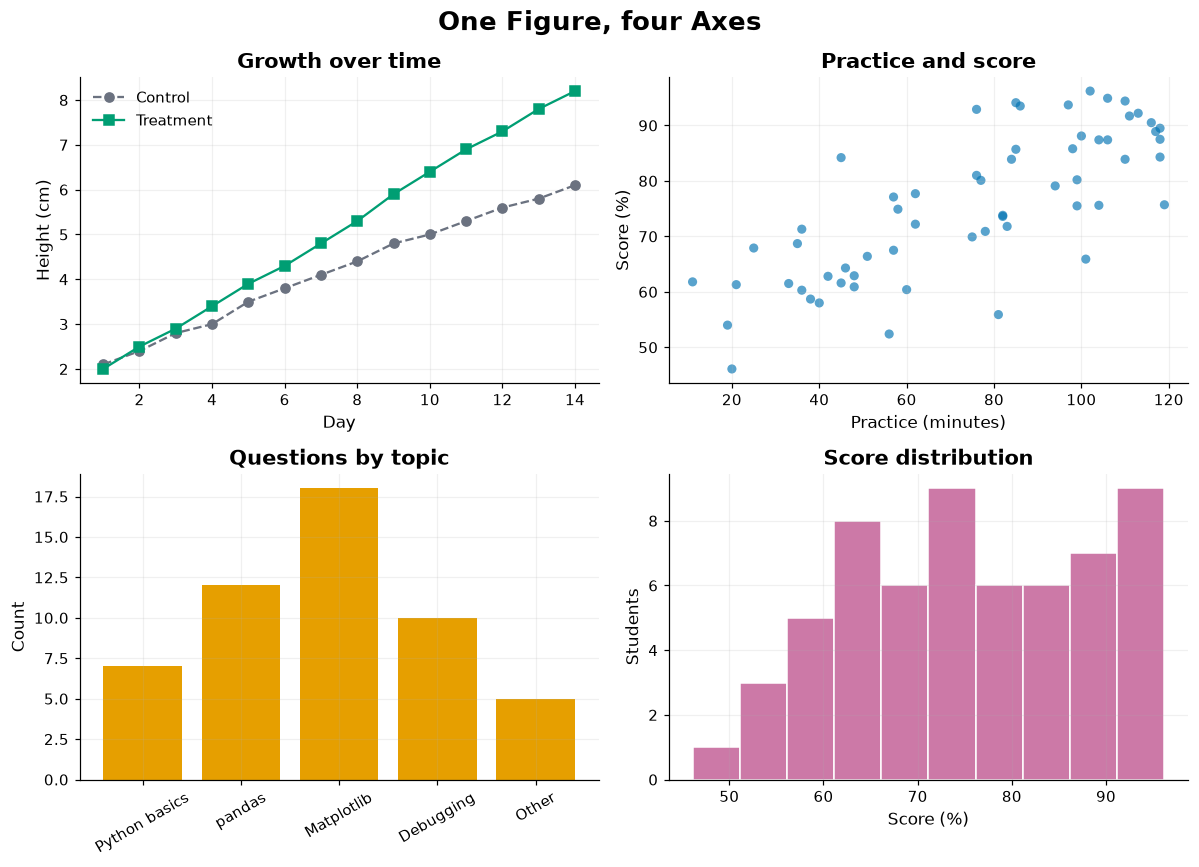

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# Top left: change over time
axes[0, 0].plot(growth["day"], growth["control_cm"],
                color=COLORS["gray"], marker="o", linestyle="--", label="Control")
axes[0, 0].plot(growth["day"], growth["treatment_cm"],
                color=COLORS["green"], marker="s", label="Treatment")
axes[0, 0].set(title="Growth over time", xlabel="Day", ylabel="Height (cm)")
axes[0, 0].legend()

# Top right: relationship
axes[0, 1].scatter(students["practice_minutes"], students["quiz_score"],
                   color=COLORS["blue"], alpha=0.65, edgecolor="none")
axes[0, 1].set(title="Practice and score", xlabel="Practice (minutes)", ylabel="Score (%)")

# Bottom left: category comparison
axes[1, 0].bar(topics.index, topics.values, color=COLORS["orange"])
axes[1, 0].set(title="Questions by topic", xlabel="", ylabel="Count")
axes[1, 0].tick_params(axis="x", rotation=30)

# Bottom right: distribution
axes[1, 1].hist(students["quiz_score"], bins=10,
                color=COLORS["purple"], edgecolor="white")
axes[1, 1].set(title="Score distribution", xlabel="Score (%)", ylabel="Students")

for ax in axes.flat:
    ax.grid(alpha=0.18)

fig.suptitle("One Figure, four Axes", fontsize=17, fontweight="bold")
fig.tight_layout()
plt.show()


## 8. A quick chart chooser

| Your question | Good first choice | Matplotlib method |
|---|---|---|
| How does a value change over ordered time? | Line plot | `ax.plot(x, y)` |
| Are two numeric variables related? | Scatter plot | `ax.scatter(x, y)` |
| How do categories compare? | Bar chart | `ax.bar(...)` or `ax.barh(...)` |
| What does one numeric variable's distribution look like? | Histogram | `ax.hist(values)` |
| How do several related views fit together? | Small multiples | `plt.subplots(...)` |

This is a starting point, not a law. The best chart is the simplest one that answers the question honestly.


<a id="debugging"></a>
## 9. Debugging clinic: common problems

### Problem A: “x and y must have same first dimension”

Every x-value needs a matching y-value. Inspect shapes before plotting.


In [15]:
x_bad = [1, 2, 3, 4]
y_bad = [10, 12, 15]

print("x length:", len(x_bad))
print("y length:", len(y_bad))
print("Fix: find the missing observation or deliberately align/filter the data.")

# This would raise a ValueError, so it is left commented out:
# fig, ax = plt.subplots()
# ax.plot(x_bad, y_bad)


x length: 4
y length: 3
Fix: find the missing observation or deliberately align/filter the data.


### A reusable “plot doctor”

When a chart errors or looks suspicious, diagnose the inputs before changing visual settings.


In [16]:
def plot_doctor(data, x_column, y_column):
    '''Print a compact pre-plot diagnostic for two DataFrame columns.'''
    x = data[x_column]
    y = data[y_column]
    report = pd.DataFrame({
        "column": [x_column, y_column],
        "dtype": [str(x.dtype), str(y.dtype)],
        "rows": [len(x), len(y)],
        "missing": [x.isna().sum(), y.isna().sum()],
        "unique": [x.nunique(dropna=True), y.nunique(dropna=True)],
    })
    print(report.to_string(index=False))
    print(f"\n{x_column!r} sorted ascending:", x.is_monotonic_increasing)


plot_doctor(growth, "day", "treatment_cm")


      column   dtype  rows  missing  unique
         day   int64    14        0      14
treatment_cm float64    14        0      14

'day' sorted ascending: True


### Problem B: unreadable category labels

Long category names collide. A horizontal bar chart is often clearer than rotating labels steeply.


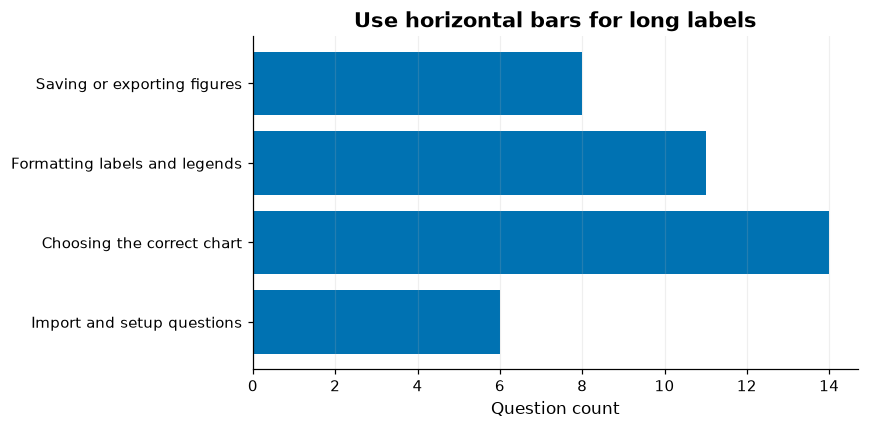

In [17]:
long_labels = [
    "Import and setup questions",
    "Choosing the correct chart",
    "Formatting labels and legends",
    "Saving or exporting figures",
]
counts = [6, 14, 11, 8]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(long_labels, counts, color=COLORS["blue"])
ax.set(title="Use horizontal bars for long labels", xlabel="Question count")
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
plt.show()


### Problem C: lines connect observations in the wrong order

`ax.plot` connects points in the order you provide them. Sort time or another ordered x-variable first.


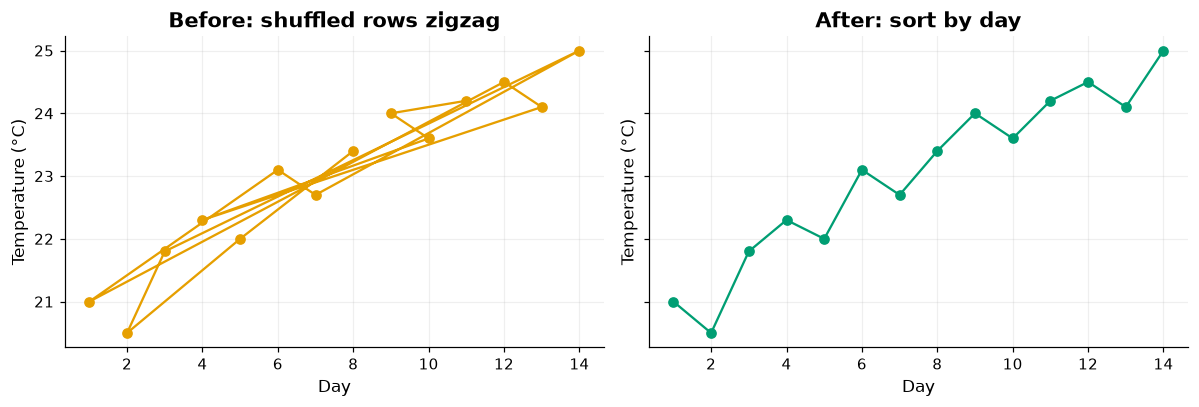

In [18]:
shuffled = growth.sample(frac=1, random_state=3)
fixed = shuffled.sort_values("day")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
axes[0].plot(shuffled["day"], shuffled["temperature_c"],
             marker="o", color=COLORS["orange"])
axes[0].set_title("Before: shuffled rows zigzag")

axes[1].plot(fixed["day"], fixed["temperature_c"],
             marker="o", color=COLORS["green"])
axes[1].set_title("After: sort by day")

for ax in axes:
    ax.set(xlabel="Day", ylabel="Temperature (°C)")
    ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()


### Problem D: missing values create gaps

Matplotlib often skips `NaN` values rather than raising an error. That can be correct, but it can also hide a data-quality problem. Inspect the relevant columns before deciding whether to drop, impute, or preserve missingness.


Missing treatment measurements:
   day  treatment_cm
6    7           NaN


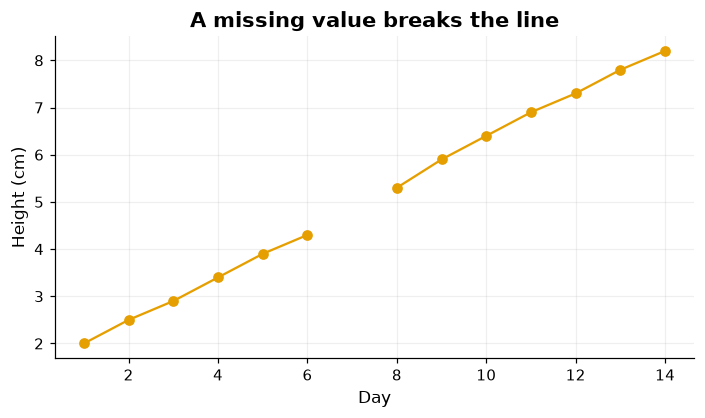

In [19]:
growth_with_gap = growth.copy()
growth_with_gap.loc[growth_with_gap["day"] == 7, "treatment_cm"] = np.nan

print("Missing treatment measurements:")
print(growth_with_gap[growth_with_gap["treatment_cm"].isna()][["day", "treatment_cm"]])

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(
    growth_with_gap["day"],
    growth_with_gap["treatment_cm"],
    color=COLORS["orange"],
    marker="o",
)
ax.set(
    title="A missing value breaks the line",
    xlabel="Day",
    ylabel="Height (cm)",
)
ax.grid(alpha=0.2)
plt.show()

# Possible next steps depend on why the value is missing:
# cleaned = growth_with_gap.dropna(subset=["treatment_cm"])
# filled = growth_with_gap.assign(
#     treatment_cm=growth_with_gap["treatment_cm"].interpolate()
# )


### Problem E: the plot is cramped, clipped, or saves poorly

Useful fixes:

```python
fig, ax = plt.subplots(figsize=(9, 5))  # make the canvas larger
fig.tight_layout()                      # reduce overlaps
fig.savefig("figure.png", dpi=300, bbox_inches="tight")
```

Save from the **Figure** object, and save before closing or clearing the figure. Use vector formats such as SVG or PDF when appropriate for publications.

### Problem F: old plots leak into new plots

Start each separate chart with `fig, ax = plt.subplots()`. This creates a fresh canvas and makes the target Axes explicit.


<a id="guided-practice"></a>
## 10. Guided practice: complete a chart

**Question:** How does average quiz score compare between sections A and B?

Plan before coding:

1. Group rows by section.
2. Calculate one mean score per section.
3. Use a bar chart because the x-variable is categorical.
4. Label the units and start the y-axis at zero.


In [20]:
# Your turn: replace the TODO comments with working code.
section_means = students.groupby("section")["quiz_score"].mean()

# fig, ax = plt.subplots()
# TODO: draw one bar per section.
# TODO: add a useful title and axis labels.
# TODO: make the y-axis begin at 0.
# plt.show()

section_means


section
A    73.423333
B    77.590000
Name: quiz_score, dtype: float64

<details>
<summary><strong>Hint</strong></summary>

Use `ax.bar(section_means.index, section_means.values)` and `ax.set_ylim(0, 100)`.

</details>


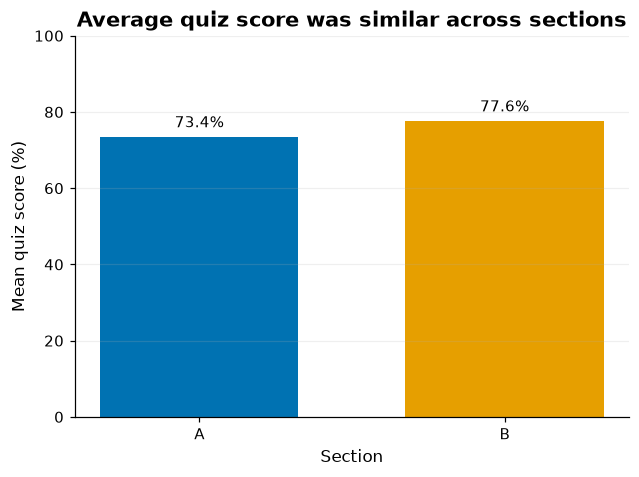

In [21]:
# One possible solution
section_means = students.groupby("section")["quiz_score"].mean()

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(
    section_means.index,
    section_means.values,
    color=[COLORS["blue"], COLORS["orange"]],
    width=0.65,
)
ax.bar_label(bars, labels=[f"{value:.1f}%" for value in section_means.values], padding=4)
ax.set(
    title="Average quiz score was similar across sections",
    xlabel="Section",
    ylabel="Mean quiz score (%)",
    ylim=(0, 100),
)
ax.grid(axis="y", alpha=0.2)

plt.show()


<a id="mini-challenge"></a>
## 11. Mini challenge: tell a two-panel story

Build a figure with:

- **Left:** control and treatment growth over time
- **Right:** the treatment advantage (`treatment_cm - control_cm`) over time

Include titles, axis labels with units, a legend where it adds meaning, and a horizontal reference line at zero on the right.

**Stretch goal:** annotate the day with the largest treatment advantage.


In [22]:
# Starter cell
growth["treatment_advantage_cm"] = (
    growth["treatment_cm"] - growth["control_cm"]
)

# fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
# TODO: draw the two panels.
# TODO: label and polish them.
# fig.tight_layout()
# plt.show()

growth[["day", "treatment_advantage_cm"]].tail()


,day,treatment_advantage_cm
9,10,1.4
10,11,1.6
11,12,1.7
12,13,2.0
13,14,2.1


### Challenge success criteria

Before opening the solution, check that:

- `axes` contains two plotting areas;
- both panels have meaningful titles and labels with units;
- the group lines are distinguishable without color alone;
- the zero reference line on the right has a clear purpose;
- the treatment advantage is computed from the data rather than typed by hand.

**Extension:** replace the right-hand line with bars, then decide which version communicates the difference more clearly.


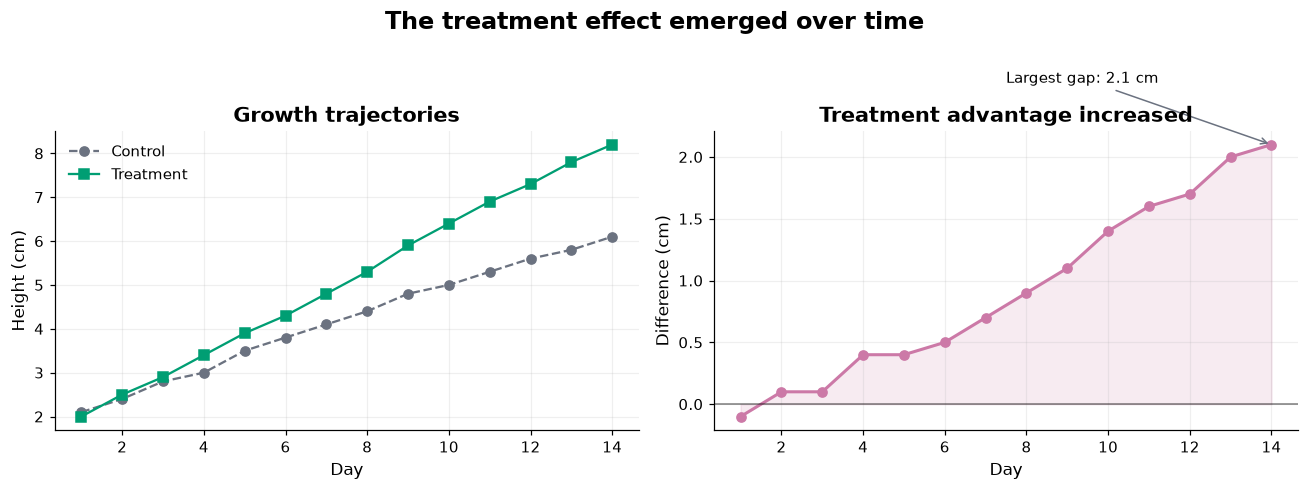

In [23]:
# One possible solution
growth["treatment_advantage_cm"] = growth["treatment_cm"] - growth["control_cm"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(growth["day"], growth["control_cm"],
             color=COLORS["gray"], marker="o", linestyle="--", label="Control")
axes[0].plot(growth["day"], growth["treatment_cm"],
             color=COLORS["green"], marker="s", label="Treatment")
axes[0].set(title="Growth trajectories", xlabel="Day", ylabel="Height (cm)")
axes[0].legend()

axes[1].plot(growth["day"], growth["treatment_advantage_cm"],
             color=COLORS["purple"], marker="o", linewidth=2)
axes[1].axhline(0, color="black", linewidth=1, alpha=0.5)
axes[1].fill_between(
    growth["day"],
    0,
    growth["treatment_advantage_cm"],
    color=COLORS["purple"],
    alpha=0.15,
)
axes[1].set(title="Treatment advantage increased", xlabel="Day", ylabel="Difference (cm)")

max_row = growth.loc[growth["treatment_advantage_cm"].idxmax()]
axes[1].annotate(
    f"Largest gap: {max_row['treatment_advantage_cm']:.1f} cm",
    xy=(max_row["day"], max_row["treatment_advantage_cm"]),
    xytext=(7.5, 2.6),
    arrowprops={"arrowstyle": "->", "color": COLORS["gray"]},
)

for ax in axes:
    ax.grid(alpha=0.2)

fig.suptitle("The treatment effect emerged over time", fontsize=16, fontweight="bold")
fig.tight_layout()
plt.show()


## 12. Your reusable plotting template

Copy this pattern when starting a new figure:

```python
# 1. Inspect and prepare data
plot_data = data.sort_values("x_column")

# 2. Create the canvas
fig, ax = plt.subplots(figsize=(8, 5))

# 3. Draw the geometry
ax.plot(plot_data["x_column"], plot_data["y_column"])

# 4. Add meaning
ax.set(
    title="A title that states the takeaway",
    xlabel="Variable name (units)",
    ylabel="Variable name (units)",
)

# 5. Polish and display
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()
```

### Final checklist

- [ ] Does the chart answer a specific question?
- [ ] Is the chart type appropriate for the variables?
- [ ] Are axes labeled with units?
- [ ] Does color communicate meaning?
- [ ] Is text readable at the intended size?
- [ ] Are comparisons shown on honest scales?
- [ ] Could anything be removed without losing meaning?


## 13. Takeaways

1. Start with the question, not the chart type.
2. Prefer the explicit `fig, ax = plt.subplots()` pattern.
3. Match the geometry to the data: line, points, bars, or bins.
4. Labels and units are part of the analysis—not decoration.
5. Inspect data shape, missing values, and sort order when a plot looks wrong.
6. Build a correct plot first; polish it in a second pass.

### Try next

- Apply the four-pass workflow to a dataset from an assignment.
- Recreate one figure you admire using only Matplotlib.
- Read the error message, isolate a minimal example, and ask a focused question.

**Questions are welcome—Matplotlib or otherwise.**


## Exit ticket

Answer these without looking back:

1. You have two numeric variables measured once per observation. Which chart is a good first choice?
2. Why should time values usually be sorted before drawing a line?
3. What are three elements that make a chart understandable without spoken explanation?

<details>
<summary><strong>Check your answers</strong></summary>

1. A scatter plot.
2. `ax.plot` connects points in row order; unsorted time can create misleading zigzags.
3. A takeaway-oriented title, axis labels with units, and a legend or direct labels for meaningful groups are strong examples.

</details>

### When you get stuck, ask these in order

1. **Data:** Are the columns present, numeric when needed, equally long, and reasonably free of missing values?
2. **Order:** Is the x-variable sorted when connections imply sequence?
3. **Target:** Am I drawing on the Axes I intended?
4. **Scale:** Do the axis limits include the data, and is the scale honest?
5. **Meaning:** Are labels, units, and legend entries accurate?

If the problem remains, reduce it to the smallest failing cell and bring that cell plus the full error message to office hours.


---

## Instructor notes (optional)

Suggested 60-minute pacing:

| Time | Segment |
|---:|---|
| 0–5 min | Goals, setup, and inspect the data |
| 5–15 min | Figure/Axes mental model and first line plot |
| 15–30 min | Scatter, bar, and histogram choices |
| 30–40 min | Subplots and visual design principles |
| 40–50 min | Debugging clinic |
| 50–60 min | Guided practice, challenge, and open questions |

For a **45-minute session**, skip the trend-line and error-bar deep dives, then demonstrate only one debugging example before guided practice. For a **75-minute session**, invite pairs to complete the mini challenge and compare design choices.

Teaching prompts:

- Ask students to predict the output before running a cell.
- Change one argument at a time (`alpha`, `bins`, `figsize`, `sharey`).
- Invite students to explain why a chart choice fits the question.
- Keep the exercise cells visible and collapse solution cells until needed.

Before students arrive:

- Restart the kernel and run all cells once.
- Collapse cells tagged `solution` if your Jupyter interface supports tags.
- Decide whether students will code along or primarily watch and predict.
- Keep a blank “parking lot” area nearby for unrelated office-hours questions.
